In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [31]:
start = '2012-01-01'
end = '2026-04-25'
stock = 'GOOG'

data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [32]:
data.reset_index(inplace=True)

In [33]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.438171,16.505861,16.116033,16.130116,147611217
1,2012-01-04,16.509073,16.557740,16.319842,16.428786,114989399
2,2012-01-05,16.280066,16.402597,16.211389,16.357142,131808205
3,2012-01-06,16.057981,16.304525,16.052298,16.283526,108119746
4,2012-01-09,15.377143,15.983376,15.346757,15.971022,233776981
...,...,...,...,...,...,...
3593,2026-04-20,335.399994,339.160004,334.630005,338.559998,12897300
3594,2026-04-21,330.470001,337.170013,329.630005,335.584991,14623800
3595,2026-04-22,337.730011,338.029999,332.959991,334.885010,12954200


In [34]:
ma_100_days = data.Close.rolling(100).mean()

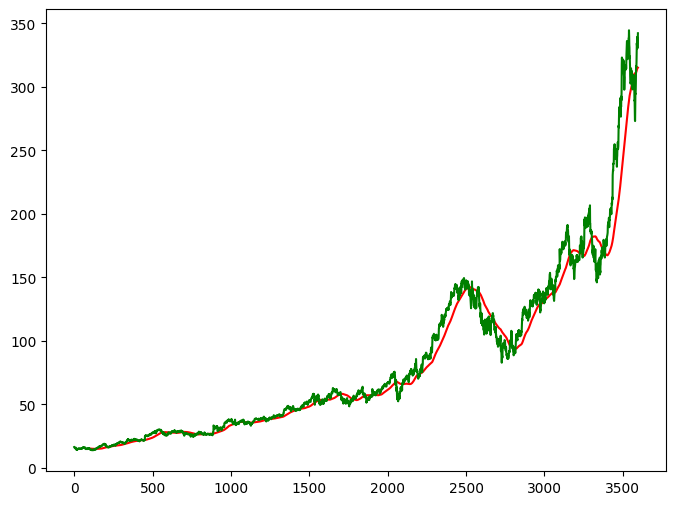

In [35]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(data.Close, 'g')
plt.show()

In [36]:
ma_200_days = data.Close.rolling(200).mean()

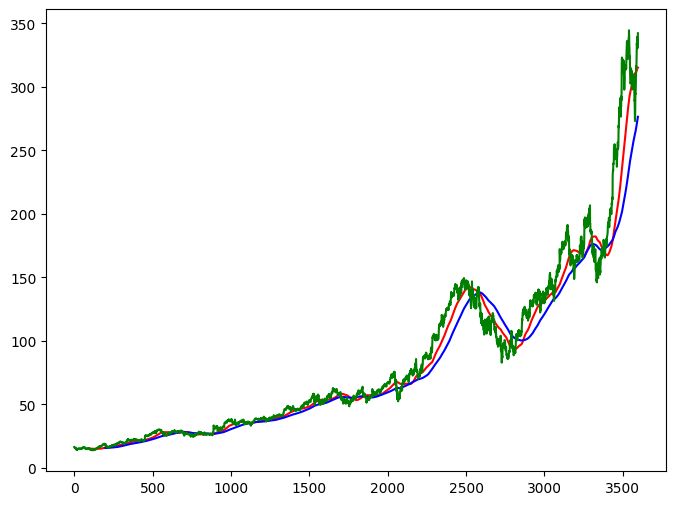

In [37]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days,'b')
plt.plot(data.Close,'g')
plt.show()

In [38]:
data.dropna(inplace=True)

In [39]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [40]:
data_train.shape[0]

2878

In [41]:
data_test.shape[0]

720

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [43]:
data_test_scale = scaler.fit_transform(data_test)

In [44]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])
    

In [45]:
x, y = np.array(x), np.array(y)

In [46]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [47]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation='relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units =1))

C:\Users\tiwar\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [49]:
model.fit(x,y, epochs = 50, batch_size =32, verbose =1)

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0264
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0063
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0054
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 0.0050
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0041
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0046
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0043
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0041
Epoch 9/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0037
Epoch 10/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0038
Epoch 11/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0034
Epoch 12/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0034
Epoch 13/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0031
Epoch 14/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0033
Epoch 15/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/ste

In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [51]:
pas_100_days = data_train.tail(100)

In [52]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [53]:
data_test_scale  =  scaler.fit_transform(data_test)

In [54]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)

In [55]:
y_predict = model.predict(x)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


In [56]:
y_predict = scaler.inverse_transform(y_predict)

In [57]:
y = scaler.inverse_transform(y.reshape(-1,1))

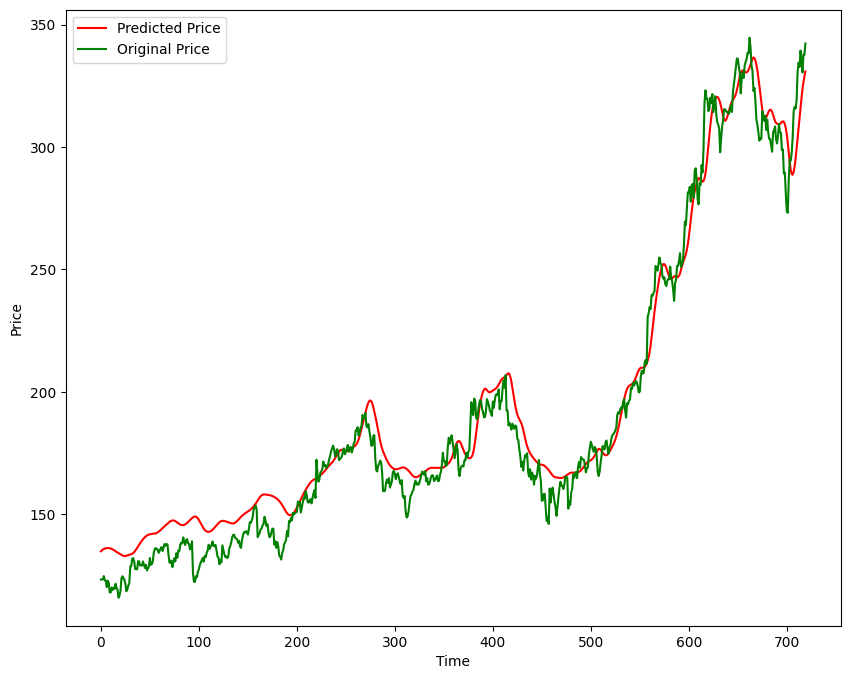

In [59]:
plt.figure(figsize=(10,8))
plt.plot(y_predict, 'r', label = 'Predicted Price')
plt.plot(y, 'g', label = 'Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [60]:
model.save('Stock Predictions Model.keras')

In [62]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))